# 01 — Exploratory Data Analysis

Examine the dataset before any preprocessing or modeling decisions; let observations drive subsequent choices. See the [Table of Contents](#toc) and [Key findings](#key-findings) below.

## Data source

Two files in `data_raw/`:
1. `census-bureau.columns` — column names (one per line)
2. `census-bureau.data` — the dataset

<a id="toc"></a>

## Table of Contents

| Section | What to read for |
|---|---|
| [Key findings](#key-findings) | Consolidated EDA findings and preprocessing decisions. |
| [Initial Observations](#initial-observations) | First-pass agenda after loading the data. |
| [Column taxonomy](#ch-taxonomy) | Column roles and categorical/numeric split. |
| [Categorical column scan](#ch-categorical) | Sentinel values, missingness, and categorical treatment decisions. |
| [Numeric descriptive analysis](#ch-numeric) | Numeric distributions, zero spikes, and top-coding. |
| [Target distribution + recode](#ch-target) | Binary target creation and class imbalance. |
| [Weight column analysis](#ch-weight) | Population weights and train/evaluate/profile decisions. |
| [Bivariate analysis vs. target](#ch-bivariate) | Feature-level income signal before modeling. |
| [Feature-engineering candidates](#ch-feature-engineering-signals) | Strong target relationships translated into candidate model features. |

<a id="key-findings"></a>

## Key findings

Each row pairs an EDA finding with the preprocessing or modeling decision it drives, plus a source link.

| # | Theme | EDA finding | Implication for preprocessing / modeling | Source |
|---|---|---|---|---|
| 1 | Shape | 199,523 records, 42 columns: 40 features + `weight` + `label`. | Reference the taxonomy for inputs; exclude `weight` and `label` from features. | [Taxonomy obs #1](#obs-taxonomy) |
| 2 | Shape | 33 categorical and 7 numeric features after recoding integer-coded fields. | Use separate preprocessing pipelines per type; never treat code-like integers as continuous. | [Taxonomy obs #3-5](#obs-taxonomy) |
| 3 | Target | Imbalance is heavy: 6.21% high-income, ~15:1 ratio. | Recode to `over_50k`; stratify val/test; rank by PR-AUC + lift, not accuracy. Compare class weights or train-only resampling on validation; reserve test for final. | [Target obs #1-2, #4](#obs-target) |
| 4 | Target | Sample vs. weighted-population target rate: 6.21% vs. 6.41% (0.20pp gap). | Train unweighted; report both sample and weighted metrics; use weighted counts for segment profiles. | [Target obs #3-4](#obs-target), [Weight obs #3-5](#obs-weight) |
| 5 | Sentinels | 11 categorical features are ≥50% `Not in universe*` — conditional questions where the sentinel means "not applicable." | Keep `Not in universe*` as its own category; do not recode to missing. | [Categorical obs #2](#obs-categorical) |
| 6 | Sentinels | `?` shows two patterns: ~50% in migration columns (year artifact, see row 12), 1.70–3.36% scattered in country-of-birth. `hispanic origin` adds 874 `NaN` and 306 `Do not know`. | Encode as an `Unknown` category. Do not impute; do not drop rows. | [Categorical obs #3-5](#obs-categorical) |
| 7 | Numerics | Four of seven numeric features are 89–98% zero; right tails are heavy; `capital gains` has 390 records at 99999 (top-coding). | Linear models: add `has_X > 0` flags, `log1p`, and `capital_gains_at_cap`. Trees: raw values are fine. | [Numeric obs #2-3](#obs-numeric), [Feature-engineering candidates](#ch-feature-engineering-signals) |
| 8 | Signal | Education is the strongest single categorical signal: doctorate/professional 53.21% high-income vs. 5.47%; bachelor-plus 25.72% vs. 2.82%. | Keep raw `education` for trees. Test tier flags (`doctorate_or_prof_degree`, `graduate_degree`, `bachelor_plus`) for linear models and segmentation. Do not collapse to PhD-only. | [Bivariate obs #1](#obs-bivariate), [Feature-engineering candidates](#ch-feature-engineering-signals) |
| 9 | Signal | Occupation, industry, and worker class carry strong signal. Executive/managerial and professional specialty are broad high-income groups; some detailed occupation codes exceed 65% high-income on small populations. | Carry detailed + major occupation/industry into the first model; use importance + ablation to decide redundancy. Test grouped high-income work flags for linear models and segmentation. | [Bivariate obs #2](#obs-bivariate), [Feature-engineering candidates](#ch-feature-engineering-signals) |
| 10 | Signal | Financial tails and labor intensity are strong binary signals: `capital gains == 99999` 88.21% high-income; `capital gains > 0` 32.69% vs. 5.19%; `dividends > 0` 25.12% vs. 3.96%; full-year work 14.80% vs. 1.53%. | Test these as binary indicators in the linear baseline. | [Bivariate obs #3](#obs-bivariate), [Feature-engineering candidates](#ch-feature-engineering-signals) |
| 11 | Signal | Household and demographics lift income rates moderately: married-civilian-spouse-present, householder, male, joint tax filing. | Keep as auxiliary features; expect interactions with education, work, and age rather than standalone effects. | [Bivariate obs #4](#obs-bivariate), [Feature-engineering candidates](#ch-feature-engineering-signals) |
| 12 | Drops | Migration fields, previous-residence fields, and `year` are low-signal univariately; detailed/coarse pairs may be redundant. The four migration columns are a year artifact: `?` rate is 0% in 1994 records and 100% in 1995 records — they encode year identity, not migration. | Drop migration columns: they duplicate `year` and add no migration signal. For the rest, defer drop decisions to importance + ablation. | [Categorical obs #3, #6-7](#obs-categorical), [Bivariate obs #5-6](#obs-bivariate) |
| 13 | Compliance | Sensitive attributes are present and carry univariate signal: `Male` 10.17% vs. 6.21% base; `Asian or Pacific Islander` 7.37%. Columns: `sex`, `race`, `hispanic origin`, `citizenship`. | Document the include/exclude decision in the report's limitations section. Marketing is lower-risk than credit/insurance, but explicit framing is required. | [Bivariate obs #4](#obs-bivariate) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

DATA_DIR = Path("../data_raw")
COLUMNS_FILE = DATA_DIR / "census-bureau.columns"
DATA_FILE = DATA_DIR / "census-bureau.data"

In [2]:
# Read column names from the columns file
with open(COLUMNS_FILE, 'r') as f:
    columns = [line.strip() for line in f if line.strip()]

print(f'Number of columns defined: {len(columns)}')
print()
for i, col in enumerate(columns, 1):
    print(f'  {i:2d}. {col}')

Number of columns defined: 42

   1. age
   2. class of worker
   3. detailed industry recode
   4. detailed occupation recode
   5. education
   6. wage per hour
   7. enroll in edu inst last wk
   8. marital stat
   9. major industry code
  10. major occupation code
  11. race
  12. hispanic origin
  13. sex
  14. member of a labor union
  15. reason for unemployment
  16. full or part time employment stat
  17. capital gains
  18. capital losses
  19. dividends from stocks
  20. tax filer stat
  21. region of previous residence
  22. state of previous residence
  23. detailed household and family stat
  24. detailed household summary in household
  25. weight
  26. migration code-change in msa
  27. migration code-change in reg
  28. migration code-move within reg
  29. live in this house 1 year ago
  30. migration prev res in sunbelt
  31. num persons worked for employer
  32. family members under 18
  33. country of birth father
  34. country of birth mother
  35. country of birth

In [3]:
# Load the data: comma delimited, no header row in the file
df = pd.read_csv(DATA_FILE, header=None, names=columns)

In [4]:
print("Shape:", df.shape)
print()
print("Dtype counts:")
print(df.dtypes.value_counts())
print()


pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df.head()

Shape: (199523, 42)

Dtype counts:
str        29
int64      12
float64     1
Name: count, dtype: int64



,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,?,?,?,Not in universe under 1 year old,?,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


<a id="initial-observations"></a>

## Initial Observations

| # | Observation | Next step |
|---|---|---|
| 1 | 199,523 rows × 42 columns. Layout matches the brief: 40 features + `weight` + `label`. | Confirm the role of each column by name. |
| 2 | Type mix: 29 string, 12 int, 1 float (`weight`). Several int columns look like categorical recodes by name. | Identify which int columns are true categorical recodes (e.g., `detailed industry recode`, `detailed occupation recode`, `year`). |
| 3 | Two distinct sentinel forms appear in `head()`: `?` and `Not in universe` (with variants like `Not in universe or children`). | Per-column sentinel scan: count `?`, `Not in universe`, and any other non-canonical values. |
| 4 | Label is a string (e.g., `- 50000.`); `head()` rows show only one class. | Compute target distribution (raw + weighted); recode to a clean binary indicator. |
| 5 | `weight` column is a float, consistent with stratified sampling per the brief. | Quantify weight distribution and decide whether to use it in training, evaluation, or both. |

<a id="ch-taxonomy"></a>

## Column taxonomy

- Address initial observation #1 & #2.
- Classify each of the 42 columns by **role** (feature / target / weight) and **modeling type** (categorical / numeric). Several integer-typed columns are categorical recodes by name, flag them now so they get treated correctly downstream.
- *For the report:* establishes the feature inventory (33 categorical + 7 numeric + target + weight) that every later section refers back to.

In [5]:
# Build a starter taxonomy: role + base modeling type for every column
def initial_role(name: str) -> str:
    if name == "label":
        return "target"
    if name == "weight":
        return "weight"
    return "feature"

def base_modeling_type(dtype) -> str:
    return "numeric" if pd.api.types.is_numeric_dtype(dtype) else "categorical"

taxonomy = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "nunique": [df[c].nunique() for c in df.columns],
    "role": [initial_role(c) for c in df.columns],
    "modeling_type": [base_modeling_type(df[c].dtype) for c in df.columns],
})

taxonomy

,column,dtype,nunique,role,modeling_type
0,age,int64,91,feature,numeric
1,class of worker,str,9,feature,categorical
2,detailed industry recode,int64,52,feature,numeric
3,detailed occupation recode,int64,47,feature,numeric
4,education,str,17,feature,categorical
5,wage per hour,int64,1240,feature,numeric
6,enroll in edu inst last wk,str,3,feature,categorical
7,marital stat,str,7,feature,categorical
8,major industry code,str,24,feature,categorical
9,major occupation code,str,15,feature,categorical


In [6]:
# Inspect int columns by cardinality
# Low-cardinality int columns are likely categorical recodes despite the int dtype
int_cols = [c for c in df.columns if pd.api.types.is_integer_dtype(df[c])]
int_summary = pd.DataFrame({
    "column": int_cols,
    "nunique": [df[c].nunique() for c in int_cols],
    "sample_values": [sorted(df[c].unique())[:10] for c in int_cols],
})
int_summary.sort_values("nunique").reset_index(drop=True)

,column,nunique,sample_values
0,year,2,"[94, 95]"
1,own business or self employed,3,"[0, 1, 2]"
2,veterans benefits,3,"[0, 1, 2]"
3,num persons worked for employer,7,"[0, 1, 2, 3, 4, 5, 6]"
4,detailed occupation recode,47,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
5,detailed industry recode,52,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
6,weeks worked in year,53,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
7,age,91,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"
8,capital losses,113,"[0, 155, 213, 323, 419, 625, 653, 772, 810, 880]"
9,capital gains,132,"[0, 114, 401, 594, 914, 991, 1055, 1086, 1090, 1111]"


In [7]:
# Override int columns to be categorical recodes
CATEGORICAL_INT_OVERRIDES = [
    "year",
    "own business or self employed",
    "veterans benefits",
    "detailed industry recode",
    "detailed occupation recode", 
]

taxonomy.loc[
    taxonomy["column"].isin(CATEGORICAL_INT_OVERRIDES),
    "modeling_type",
] = "categorical"


taxonomy_counts = (
    taxonomy
    .groupby(["role", "modeling_type"])
    .size()
    .reset_index(name="count")
)

print("Taxonomy counts:")
print(taxonomy_counts.to_string(index=False))
print()

taxonomy

Taxonomy counts:
   role modeling_type  count
feature   categorical     33
feature       numeric      7
 target   categorical      1
 weight       numeric      1



,column,dtype,nunique,role,modeling_type
0,age,int64,91,feature,numeric
1,class of worker,str,9,feature,categorical
2,detailed industry recode,int64,52,feature,categorical
3,detailed occupation recode,int64,47,feature,categorical
4,education,str,17,feature,categorical
5,wage per hour,int64,1240,feature,numeric
6,enroll in edu inst last wk,str,3,feature,categorical
7,marital stat,str,7,feature,categorical
8,major industry code,str,24,feature,categorical
9,major occupation code,str,15,feature,categorical


<a id="obs-taxonomy"></a>

### Observations

| # | Observation | Next step |
|---|---|---|
| 1 | 42 columns classified: 1 target (`label`), 1 weight (`weight`), 40 features. | Use `taxonomy` as the reference for downstream preprocessing. |
| 2 | 28 string features are unambiguously categorical. | Carry to sentinel scan. |
| 3 | 5 int features are confirmed categorical recodes by low cardinality and code-like values: `detailed industry recode` (52), `detailed occupation recode` (47), `year` (2), `own business or self employed` (3), `veterans benefits` (3). | Override applied already. |
| 4 | `num persons worked for employer` has 7 values (0–6) — borderline. The naming reads as a count, so it stays numeric. | Revisit if model behavior on it looks off. |
| 5 | Final taxonomy: **33 categorical features + 7 numeric features**, plus 1 target and 1 weight. | Proceed to per-column sentinel/missingness scan (categorical). |
| 6 | 7 numeric features identified — distributional shape, outliers, and zero-spike behavior need inspection before any scaling or transformation decision. | Per-column `describe()` + histograms; flag zero-spikes and heavy tails. |

<a id="ch-categorical"></a>

## Categorical column scan

- Address initial observation #3.
- For each of the 33 categorical features, count sentinel forms (`?`, `Not in universe*`, `NaN`, `Do not know`) and surface top values. Decide per-column treatment for sentinels.
- *For the report:* explains why missing-value sentinels are encoded as categories rather than imputed or dropped, and separates structural absence (`Not in universe*`) from true missingness (`?`, `NaN`, `Do not know`).

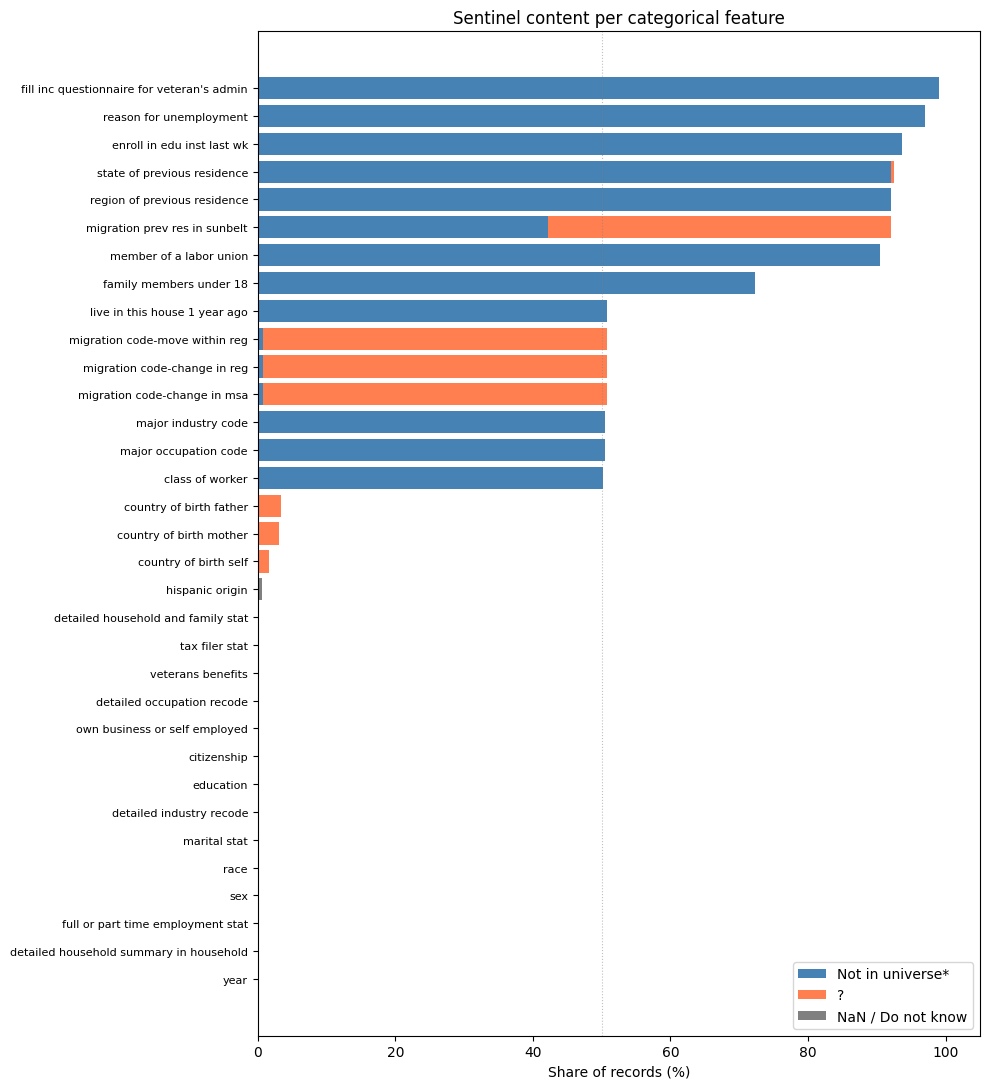

,column,nunique,top_value,pct_q,pct_niv,pct_other,pct_total_sentinel
0,fill inc questionnaire for veteran's admin,3,Not in universe,0.00,99.01,0.0,99.01
1,reason for unemployment,6,Not in universe,0.00,96.96,0.0,96.96
2,enroll in edu inst last wk,3,Not in universe,0.00,93.69,0.0,93.69
3,state of previous residence,51,Not in universe,0.35,92.09,0.0,92.45
4,region of previous residence,6,Not in universe,0.00,92.09,0.0,92.09
5,migration prev res in sunbelt,4,?,49.97,42.13,0.0,92.09
6,member of a labor union,3,Not in universe,0.00,90.45,0.0,90.45
7,family members under 18,5,Not in universe,0.00,72.29,0.0,72.29
8,live in this house 1 year ago,3,Not in universe under 1 year old,0.00,50.73,0.0,50.73
9,migration code-move within reg,10,?,49.97,0.76,0.0,50.73


In [ ]:
# Sentinel summary across all categorical features
cat_features = taxonomy.loc[
    (taxonomy["role"] == "feature") & (taxonomy["modeling_type"] == "categorical"),
    "column",
].tolist()


def sentinel_breakdown(s: pd.Series) -> dict:
    n = len(s)
    nan_n = s.isna().sum()
    s_str = s.dropna().astype(str).str.strip()
    q = (s_str == "?").sum()
    niv = s_str.str.startswith("Not in universe").sum()
    dnk = (s_str == "Do not know").sum()
    return {
        "pct_q": q / n * 100,
        "pct_niv": niv / n * 100,
        "pct_other": (nan_n + dnk) / n * 100,
        "pct_total_sentinel": (q + niv + nan_n + dnk) / n * 100,
    }


rows = []
for c in cat_features:
    s = df[c]
    top = s.value_counts(dropna=False).head(1)
    rows.append({
        "column": c,
        "nunique": s.nunique(),
        "top_value": str(top.index[0])[:35],
        **sentinel_breakdown(s),
    })

cat_summary = (
    pd.DataFrame(rows)
    .sort_values("pct_total_sentinel", ascending=False)
    .reset_index(drop=True)
)

# Stacked horizontal bar — sentinel content per categorical feature
order = cat_summary.sort_values("pct_total_sentinel", ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 11))
y = np.arange(len(order))
ax.barh(y, order["pct_niv"], color="steelblue", label="Not in universe*")
ax.barh(y, order["pct_q"], left=order["pct_niv"], color="coral", label="?")
ax.barh(y, order["pct_other"], left=order["pct_niv"] + order["pct_q"], color="gray", label="NaN / Do not know")
ax.set_yticks(y)
ax.set_yticklabels(order["column"], fontsize=8)
ax.set_xlabel("Share of records (%)")
ax.set_title("Sentinel content per categorical feature")
ax.set_xlim(0, 105)
ax.axvline(50, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

# Compact audit table — top 10 sentinel-heaviest columns.
cat_summary.head(10).round(2)

In [ ]:
# Spot-check value distribution on the top-5 sentinel-heaviest columns
for c in cat_summary.head(5)["column"]:
    print(f"--- {c} (nunique={df[c].nunique(dropna=False)}) ---")
    print(df[c].value_counts(dropna=False).head(8))
    print()

--- fill inc questionnaire for veteran's admin (nunique=3) ---
fill inc questionnaire for veteran's admin
Not in universe    197539
No                   1593
Yes                   391
Name: count, dtype: int64

--- reason for unemployment (nunique=6) ---
reason for unemployment
Not in universe          193453
Other job loser            2038
Re-entrant                 2019
Job loser - on layoff       976
Job leaver                  598
New entrant                 439
Name: count, dtype: int64

--- enroll in edu inst last wk (nunique=3) ---
enroll in edu inst last wk
Not in universe          186943
High school                6892
College or university      5688
Name: count, dtype: int64

--- state of previous residence (nunique=51) ---
state of previous residence
Not in universe    183750
California           1714
Utah                 1063
Florida               849
North Carolina        812
?                     708
Abroad                671
Oklahoma              626
Name: count, dtype: 

In [ ]:
# Year as a structural axis: does the 94/95 split create artifacts?
# (1) Target-rate drift between years; (2) migration `?` pattern by year.

target_by_year = pd.DataFrame({
    "rows": df.groupby("year").size(),
    "positive_rate_pct": df.groupby("year")["over_50k"].mean() * 100,
    "weighted_positive_rate_pct": df.groupby("year").apply(
        lambda g: (g["over_50k"] * g["weight"]).sum() / g["weight"].sum() * 100,
        include_groups=False,
    ),
})
print("Positive rate by year:")
print(target_by_year.round(3).to_string())
print()

migration_cols = [
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg",
    "migration prev res in sunbelt",
]
mig_q_by_year = pd.DataFrame({
    col: df.groupby("year")[col].apply(lambda s: (s.astype(str).str.strip() == "?").mean() * 100)
    for col in migration_cols
}).T
mig_q_by_year.columns = [f"year={y}" for y in mig_q_by_year.columns]
mig_q_by_year["overall"] = [
    (df[c].astype(str).str.strip() == "?").mean() * 100 for c in migration_cols
]

# Figure — `?` rate per migration column, split by year.
fig, ax = plt.subplots(figsize=(10, 4))
y_pos = np.arange(len(migration_cols))
ax.barh(y_pos - 0.2, mig_q_by_year["year=94"], height=0.4, color="steelblue", label="1994")
ax.barh(y_pos + 0.2, mig_q_by_year["year=95"], height=0.4, color="coral", label="1995")
ax.set_yticks(y_pos)
ax.set_yticklabels(migration_cols, fontsize=9)
ax.set_xlabel("`?` share within year (%)")
ax.set_title("Migration columns: `?` rate is structurally tied to year")
ax.set_xlim(0, 105)
ax.legend(loc="center right")
fig.tight_layout()
plt.show()

mig_q_by_year.round(2)

<a id="obs-categorical"></a>

### Observations

| # | Observation | Next step |
|---|---|---|
| 1 | 14 of 33 categorical features have **zero sentinel content**; the remaining 19 carry sentinels in some form. | The 14 clean columns can be one-hot encoded directly. |
| 2 | 11 features have **≥50% `Not in universe*`** — these are conditional questions where the sentinel itself signals "doesn't apply" (e.g., `reason for unemployment` only applies if unemployed; `enroll in edu inst last wk` only to students). | **Keep `Not in universe*` as its own category** in encoding — it carries information, do not treat as missing. |
| 3 | The four migration columns (`migration code-change in msa`, `... in reg`, `... move within reg`, `migration prev res in sunbelt`) show ~49.97% `?` overall. **Year-split scan shows the `?` rate is 0.00% in 1994 and 100.00% in 1995** — the column encodes year identity, not migration missingness. | Migration columns are strong drop candidates: they duplicate `year` and carry no migration signal. Confirms direction of [Key findings row 12](#key-findings). |
| 4 | `country of birth father/mother/self` show 1.70–3.36% `?` — scattered true missingness, not structural. | Treat `?` as a separate "unknown" category. (Imputation from within-family is possible but biased; flagging is safer.) |
| 5 | `hispanic origin` is the only column with both `NaN` (874) and `"Do not know"` (306) — combined ≈0.59%. | Recode `NaN` and `"Do not know"` into a single `Unknown` category. |
| 6 | **Drop / consolidation candidates** flagged for empirical testing (not dropped now). <br><br>**Redundancy pairs** (detailed vs. coarse — same signal, different granularity): `detailed industry recode` (52) vs `major industry code` (24); `detailed occupation recode` (47) vs `major occupation code` (15); `detailed household and family stat` (38) vs `detailed household summary in household` (8); `state of previous residence` (51) vs `region of previous residence` (6). <br><br>**Year-encoded (per row 3)**: 4 migration columns. <br><br>**Likely correlated**: 3 country-of-birth columns (`father`, `mother`, `self`). <br><br>**Likely uninformative**: `year` (only 94/95 — survey artifact, not predictive signal). <br><br>**High cardinality + heavy sentinel** (one-hot expensive for linear models): `state of previous residence` (51 values, 92% Not in universe). | Test each candidate in the modeling notebook via feature importance + ablation. Pre-dropping replaces evidence with intuition; tree-based models in particular absorb redundancy gracefully. |
| 7 | **Year drift on target is mild**: weighted positive rate 6.06% (1994) vs. 6.74% (1995), a 0.68pp gap. Record split is 50.03% / 49.97% across years. | No year-aware modeling needed. `year` is low-signal on its own; the migration-column artifact (row 3) is the stronger reason to drop those four columns than year drift alone would be. |

<a id="ch-numeric"></a>

## Numeric descriptive analysis

- Address Column Taxonomy observation #6.
- For each of the 7 numeric features, examine `describe()` summary statistics, zero-spike pattern, and distribution shape (linear and non-zero) to drive scaling and transformation decisions.
- *For the report:* documents zero-inflation, heavy tails, and top-coding — the evidence behind the linear-model preprocessing choices (`has_X` flags, log transforms, `capital_gains_at_cap` indicator).

In [ ]:
# Numeric describe() + zero-pct per feature
numeric_features = taxonomy.loc[
    (taxonomy["role"] == "feature") & (taxonomy["modeling_type"] == "numeric"),
    "column",
].tolist()

desc = df[numeric_features].describe().T
desc["pct_zero"] = [(df[c] == 0).mean() * 100 for c in numeric_features]
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,pct_zero
age,199523.0,34.49,22.31,0.0,15.0,33.0,50.0,90.0,1.42
wage per hour,199523.0,55.43,274.90,0.0,0.0,0.0,0.0,9999.0,94.33
capital gains,199523.0,434.72,4697.53,0.0,0.0,0.0,0.0,99999.0,96.30
capital losses,199523.0,37.31,271.90,0.0,0.0,0.0,0.0,4608.0,98.04
dividends from stocks,199523.0,197.53,1984.16,0.0,0.0,0.0,0.0,99999.0,89.40
num persons worked for employer,199523.0,1.96,2.37,0.0,0.0,1.0,4.0,6.0,48.11
weeks worked in year,199523.0,23.17,24.41,0.0,0.0,8.0,52.0,52.0,48.11


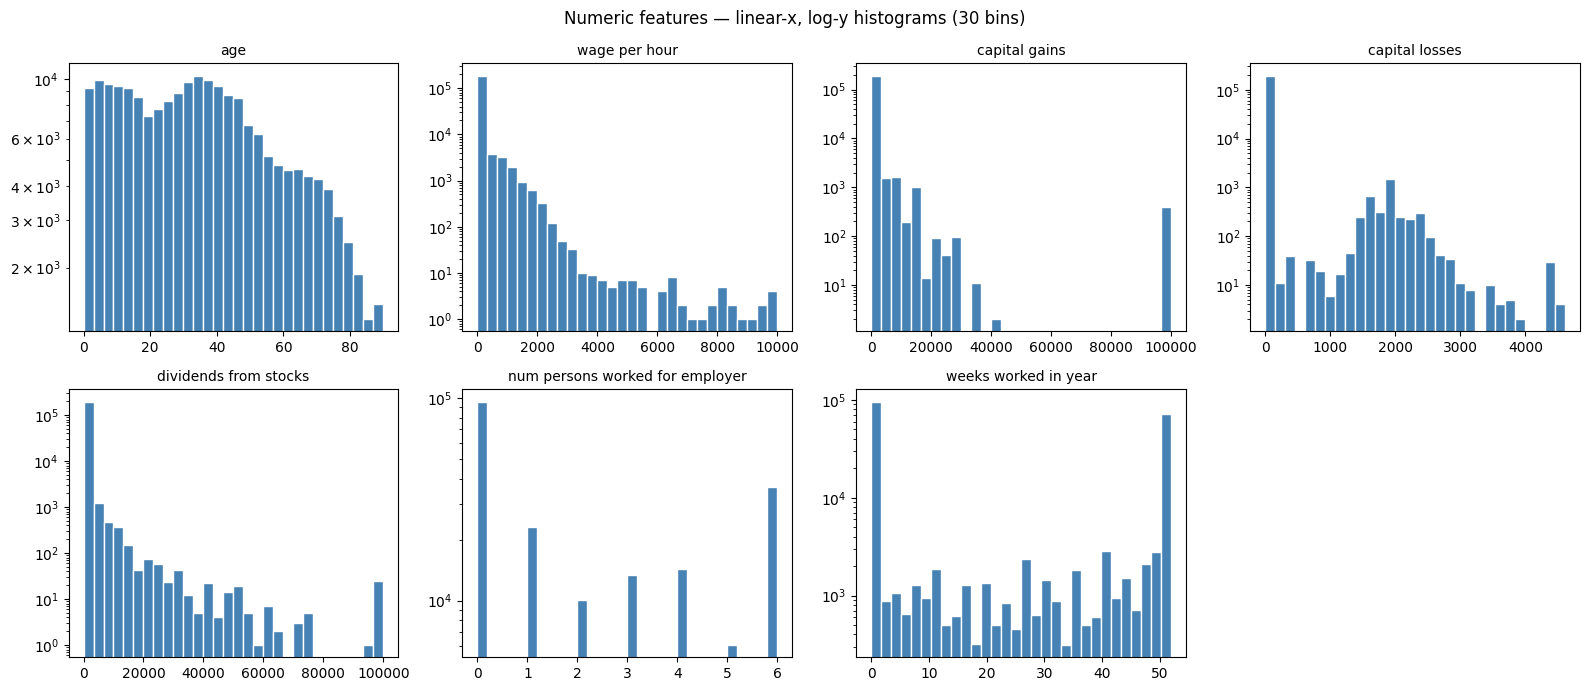

In [ ]:
# Histograms — linear-x with log-y so both the zero-spike and the tail are visible
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, c in enumerate(numeric_features):
    axes[i].hist(df[c], bins=30, color="steelblue", edgecolor="white")
    axes[i].set_yscale("log")
    axes[i].set_title(c, fontsize=10)

axes[7].axis("off")
fig.suptitle("Numeric features — linear-x, log-y histograms (30 bins)", fontsize=12)
fig.tight_layout()
plt.show()

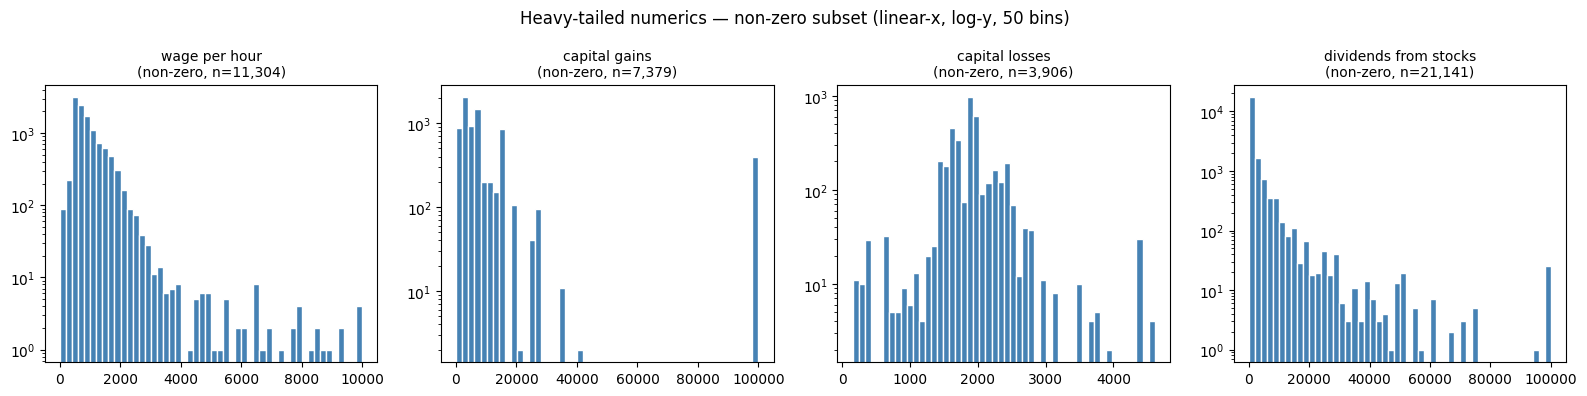

In [ ]:
# Non-zero distribution for the 4 heavy-tailed columns — the actual signal lives here
heavy_tailed = ["wage per hour", "capital gains", "capital losses", "dividends from stocks"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, c in enumerate(heavy_tailed):
    nz = df[df[c] > 0][c]
    axes[i].hist(nz, bins=50, color="steelblue", edgecolor="white")
    axes[i].set_yscale("log")
    axes[i].set_title(f"{c}\n(non-zero, n={len(nz):,})", fontsize=10)

fig.suptitle("Heavy-tailed numerics — non-zero subset (linear-x, log-y, 50 bins)", fontsize=12)
fig.tight_layout()
plt.show()

<a id="obs-numeric"></a>

### Observations

| # | Observation | Next step |
|---|---|---|
| 1 | `age`, `num persons worked for employer`, `weeks worked in year` are well-behaved (bounded ranges, count semantics). | Pass through unscaled to tree models; standardize for linear models. |
| 2 | Four features are heavily zero-inflated: `capital losses` (98.04% zero), `capital gains` (96.30%), `wage per hour` (94.33%), `dividends from stocks` (89.40%). The non-zero minority is where the signal lives. | Consider engineering a `has_X > 0` binary flag alongside the raw value, or a log-transform with offset. Tree models can absorb the spike directly; linear models need transformation. |
| 3 | `capital gains` shows **clear top-coding**: 390 records (5.29% of non-zero) sit at the max value `99999`. `dividends from stocks` has 25 records at `99999` (marginal top-coding). `wage per hour` (1 record at 9999) and `capital losses` (4 at 4608) appear to have legitimate maxima. | For `capital gains`: treat `99999` as a separate "≥cap" indicator, or cap at a lower value (e.g., 99th percentile of non-zero). Decide empirically. |
| 4 | `num persons worked for employer` and `weeks worked in year` share 48.11% zeros — the "not in the labor force" population. This matches the categorical sentinel rate for `class of worker` (50.24% `Not in universe`), pointing to consistent encoding across types. | The numeric-zero here is semantically equivalent to `Not in universe` elsewhere. A derived "in labor force" indicator could consolidate the signal across columns; test in modeling. |
| 5 | Non-zero distributions for `capital gains` (mean ≈11,755 among 3.70% with gains) and `dividends from stocks` (mean ≈1,864 among 10.60% with dividends) are heavily right-skewed. | Log-transform these for linear-model use. |

<a id="ch-target"></a>

## Target distribution + recode

- Address initial observation #4.
- Recode `label` to a clean binary indicator `over_50k` (`0` = ≤$50K, `1` = >$50K). Quantify the class distribution both raw (record-level) and weighted (population-level) to inform evaluation strategy.
- *For the report:* establishes the class-imbalance ratio (~15:1) and motivates ranking-oriented evaluation (PR-AUC, lift) over accuracy.

In [13]:
# Recode the income label to a clean binary indicator. Keep the original column for audit
LABEL_MAP = {"- 50000.": 0, "50000+.": 1}
df["over_50k"] = df["label"].map(LABEL_MAP)

assert df["over_50k"].notna().all(), "Unexpected label value mapped to NaN"
df[["label", "over_50k"]].drop_duplicates().reset_index(drop=True)

,label,over_50k
0,- 50000.,0
1,50000+.,1


In [14]:
# Raw and weighted distribution per class
dist = (
    df.groupby("label", observed=True)
      .agg(count=("label", "size"),
           weight_sum=("weight", "sum"))
)
dist["pct"] = dist["count"] / dist["count"].sum() * 100
dist["weighted_pct"] = dist["weight_sum"] / dist["weight_sum"].sum() * 100
dist.round(2)

,count,weight_sum,pct,weighted_pct
label,,,,
- 50000.,187141,3.250046e+08,93.79,93.59
50000+.,12382,2.224125e+07,6.21,6.41


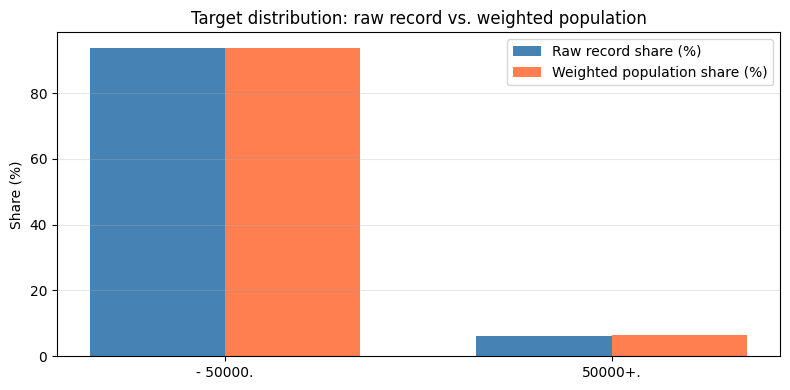

In [15]:
# Side-by-side: raw record share vs. weighted population share per class
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(dist))
width = 0.35

ax.bar(x - width / 2, dist["pct"], width, label="Raw record share (%)", color="steelblue")
ax.bar(x + width / 2, dist["weighted_pct"], width, label="Weighted population share (%)", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(dist.index)
ax.set_ylabel("Share (%)")
ax.set_title("Target distribution: raw record vs. weighted population")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

<a id="obs-target"></a>

### Observations

| # | Observation | Next step |
|---|---|---|
| 1 | Recode succeeded: `- 50000.` → 0 (187,141 rows), `50000+.` → 1 (12,382 rows). No `NaN` introduced. | Use `over_50k` as the modeling target going forward. |
| 2 | **Heavy class imbalance** — only ≈6.21% of records (and ≈6.41% of the weighted population) are in the high-income class. Imbalance ratio ≈15:1. | Preserve the original class distribution in validation/test. Compare imbalance-aware training options such as class weights, train-only oversampling, or train-only undersampling if baseline learning is weak. Rely on PR-AUC, ROC-AUC, calibration, and lift for evaluation; do not default the threshold to 0.5. |
| 3 | Sample distribution is very close to population distribution: 6.21% (raw) vs. 6.41% (weighted) — a 0.20 percentage-point gap. The stratified sampling did **not** materially over- or under-represent the high-income class. | Sample-level metrics closely approximate population-level metrics. Reporting both is still worthwhile for transparency, but the gap will be small throughout. |
| 4 | Class weights, oversampling, or undersampling are options for handling imbalance. | Apply these only to training data and choose among them on validation. The primary controls for the marketing use case remain **threshold tuning** and **ranked lift**, since the client wants prioritized prospects, not only a fixed-threshold classifier. |
| 5 | With the target now in clean binary form and per-feature analysis complete, the next analytical question is **which features distinguish the high-income minority**. | Bivariate analysis: income rate by category (categoricals); distribution by class (numerics). |

> **Note on splitting + sampling.** Random splitting is unbiased and should land close to the population class rate at this dataset size; stratification is only a low-cost safeguard to preserve that rate more exactly. Over/under-sampling is different — it intentionally changes the **training** class mix or example weights. Validation is kept separate from training so the model family, feature set, sampling strategy, and targeting threshold can all be selected before the untouched test set is used once for final evaluation.

<a id="ch-weight"></a>

## Weight column analysis

- Address initial observation #5.
- Quantify the weight distribution, sanity-check the implied population, and check whether weighting materially shifts the target balance. Decide whether to use the weight column in training, in evaluation, or both.
- *For the report:* justifies the train-unweighted / evaluate-both / profile-segments-weighted decision and surfaces the implied population (~347M) the sample represents.

In [16]:
# Weight summary statistics + total weight (= implied population).
print(df["weight"].describe().round(2).to_string())
print()
print(f"Total weight: {df['weight'].sum():,.0f}  (implied population represented by {len(df):,} records)")

count    199523.00
mean       1740.38
std         993.77
min          37.87
25%        1061.62
50%        1618.31
75%        2188.61
max       18656.30

Total weight: 347,245,892  (implied population represented by 199,523 records)


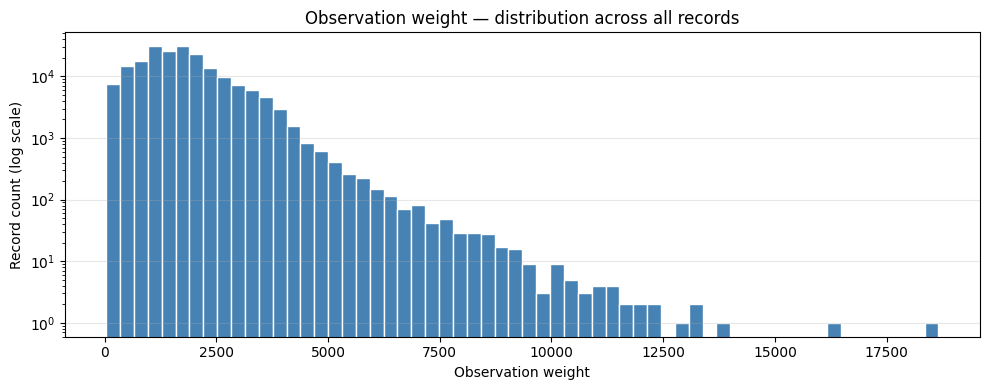

In [ ]:
# Histogram — log-y so the right tail is visible alongside the bulk
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["weight"], bins=60, color="steelblue", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Observation weight")
ax.set_ylabel("Record count (log scale)")
ax.set_title("Observation weight — distribution across all records")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

In [18]:
# Mean weight by target class — does weighting shift the high-income share materially?
weight_by_class = (
    df.groupby("over_50k")["weight"]
      .agg(["mean", "median", "sum", "count"])
      .round(2)
)
weight_by_class.index = ["≤50K (0)", ">50K (1)"]
weight_by_class

,mean,median,sum,count
≤50K (0),1736.68,1612.93,3.250046e+08,187141
>50K (1),1796.26,1684.10,2.224125e+07,12382


<a id="obs-weight"></a>

### Observations

| # | Observation | Next step |
|---|---|---|
| 1 | Weight is a continuous float, range ~37.87 to ~18,656 (median ~1,618, mean ~1,740), right-skewed with a long tail. Total weight ≈ **347M** — the implied population the 199,523 records represent. | Treat as a row-level population-scaling factor; not a feature. |
| 2 | Mean weight by class: ≤50K → 1,736.68; >50K → 1,796.26. High-income records carry ≈3.3% more weight on average — consistent with high-income being slightly underrepresented in the sample (matches the 6.21% → 6.41% gap from [target obs #3](#obs-target)). | Weighting will not materially shift model behavior. |
| 3 | **Training decision**: train **unweighted**. | Sample-vs-population gap is 0.20pp; weighted training adds engineering complexity for negligible benefit. Easy to flip later if model behavior suggests otherwise. |
| 4 | **Evaluation decision**: report both **sample** and **weighted-population** metrics. | At evaluation time, compute PR-AUC, ROC-AUC, calibration, and lift twice — once with `sample_weight=None`, once with `sample_weight=df["weight"]`. Reporting both confirms results generalize from sample to population. |
| 5 | **Segmentation decision**: use **weighted** counts for segment sizes and demographic profiles. | Pass `weight` into segment profiling, not into clustering itself — cluster on attribute distance, profile in population terms (marketing claims are population-level). |

<a id="ch-bivariate"></a>

## Bivariate analysis vs. target

- Address Target Distribution observation #5.
- For each feature, examine its relationship with `over_50k`. Categoricals: income rate and lift per category. Numerics: distribution by class.
- These signals are **univariate only** — features that look predictive in isolation may share variance with others (e.g., education and occupation). The classification model in the next notebook will resolve overlaps via multivariate feature importance.
- *For the report:* identifies the strongest univariate predictors (education, occupation, financial tail features) and sets up the multivariate feature-importance check that follows in modeling.

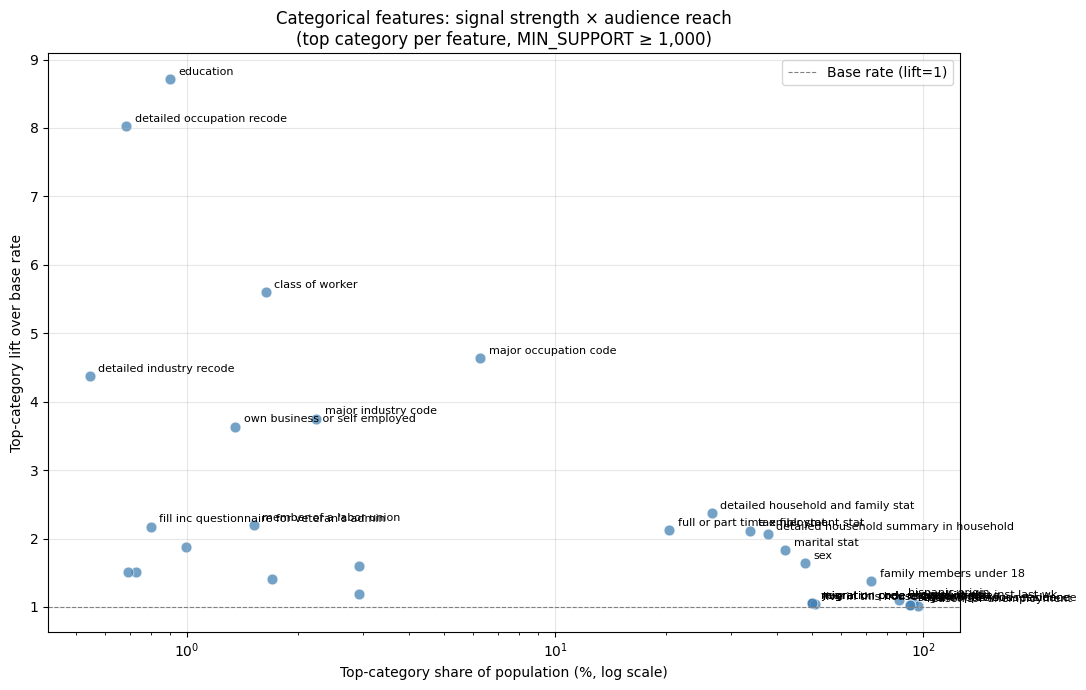

,column,top_category,top_income_rate_pct,top_lift,top_share_pop_pct,spread_pct
0,education,Prof school degree (MD DDS DVM LLB JD),54.04,8.71,0.90,54.04
1,detailed occupation recode,4,49.78,8.02,0.68,49.23
2,class of worker,Self-employed-incorporated,34.73,5.60,1.64,33.83
3,major occupation code,Executive admin and managerial,28.76,4.63,6.26,27.86
4,detailed industry recode,25,27.12,4.37,0.54,26.22
5,major industry code,Other professional services,23.29,3.75,2.25,22.39
6,own business or self employed,1,22.57,3.64,1.35,16.79
7,detailed household and family stat,Householder,14.74,2.38,26.69,14.74
8,tax filer stat,Joint both under 65,13.14,2.12,33.77,13.09
9,detailed household summary in household,Householder,12.79,2.06,37.83,12.78


In [ ]:
# Categorical feature lift summary: top category per feature, lift over base rate, and audience reach
# MIN_SUPPORT filters out tiny categories whose rates are noisy
base_rate = df["over_50k"].mean()
MIN_SUPPORT = 1000

rows = []
for c in cat_features:
    g = df.groupby(c, observed=True)["over_50k"]
    rate = g.mean()
    count = g.size()
    valid = count[count >= MIN_SUPPORT].index
    if len(valid) == 0:
        continue
    rate_v = rate.loc[valid]
    top_cat = rate_v.idxmax()
    rows.append({
        "column": c,
        "top_category": str(top_cat)[:40],
        "top_income_rate_pct": rate_v.max() * 100,
        "top_lift": rate_v.max() / base_rate,
        "top_share_pop_pct": count.loc[top_cat] / len(df) * 100,
        "spread_pct": (rate_v.max() - rate_v.min()) * 100,
    })

cat_lift = (
    pd.DataFrame(rows)
    .sort_values("spread_pct", ascending=False)
    .reset_index(drop=True)
)

# Scatter — signal strength × audience reach, one point per categorical feature
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(
    cat_lift["top_share_pop_pct"],
    cat_lift["top_lift"],
    s=60, color="steelblue", alpha=0.75, edgecolor="white", linewidth=0.5,
)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Base rate (lift=1)")

# Label features that stand out: high lift, high reach, or both
for _, row in cat_lift.iterrows():
    if row["top_lift"] >= 2.0 or row["top_share_pop_pct"] >= 25:
        ax.annotate(
            row["column"],
            (row["top_share_pop_pct"], row["top_lift"]),
            fontsize=8,
            xytext=(6, 3),
            textcoords="offset points",
        )

ax.set_xscale("log")
ax.set_xlabel("Top-category share of population (%, log scale)")
ax.set_ylabel("Top-category lift over base rate")
ax.set_title("Categorical features: signal strength × audience reach\n(top category per feature, MIN_SUPPORT ≥ 1,000)")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Compact audit table — top 10 by spread (most discriminative)
cat_lift.head(10).round(2)

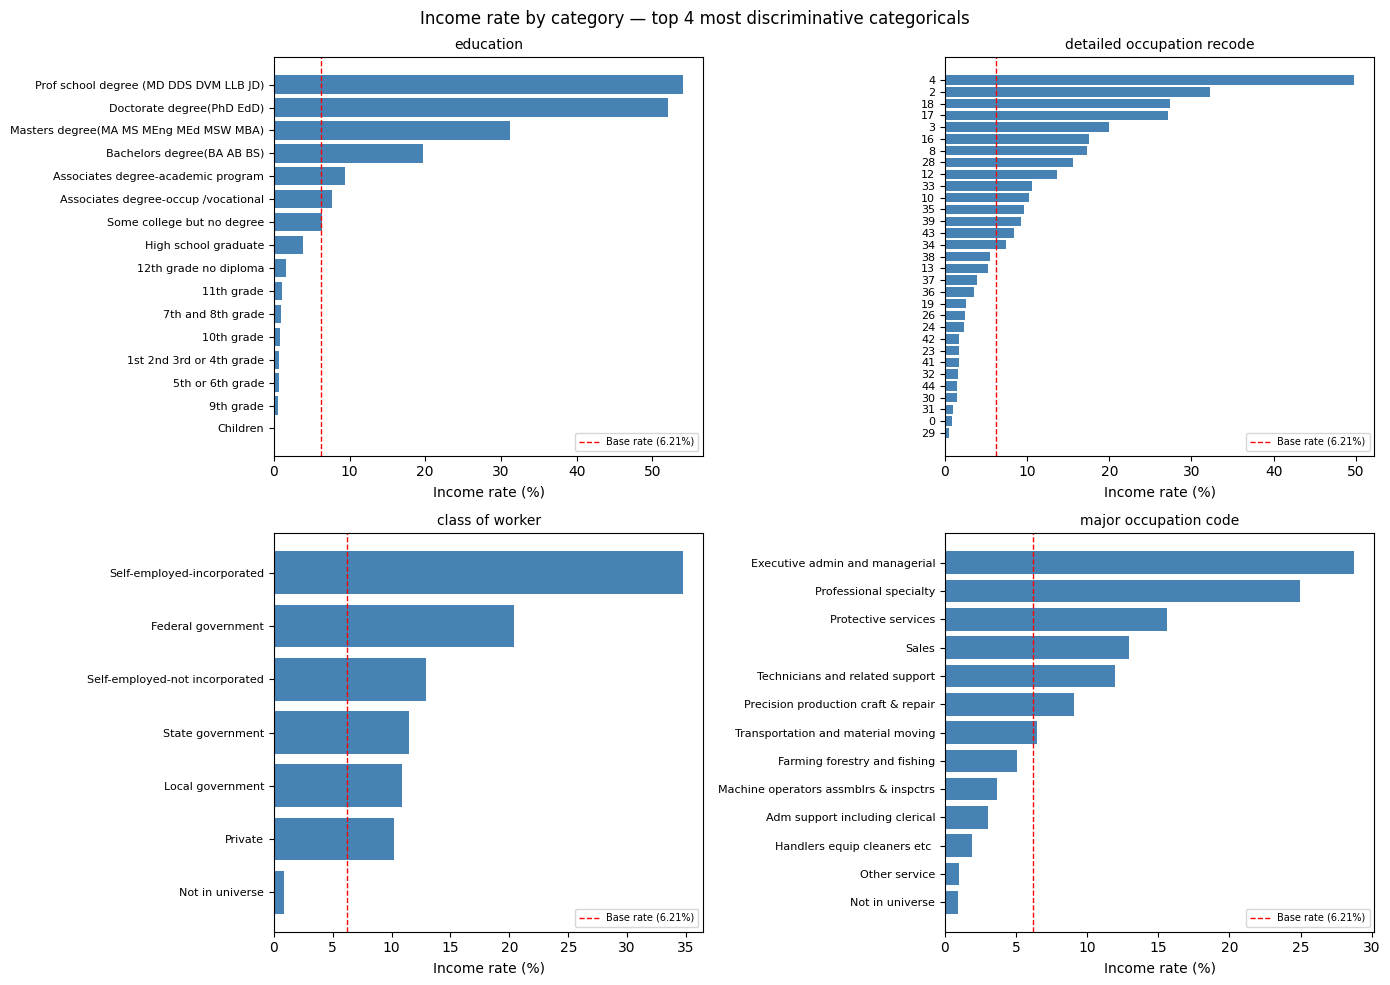

In [ ]:
# Income rate by category — top 4 most discriminative categoricals (by spread)
top4 = cat_lift.head(4)["column"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, c in enumerate(top4):
    g = (
        df.groupby(c, observed=True)
          .agg(income_rate=("over_50k", "mean"), n=("over_50k", "size"))
    )
    g = g[g["n"] >= MIN_SUPPORT].sort_values("income_rate")
    g["income_rate_pct"] = g["income_rate"] * 100

    axes[i].barh(range(len(g)), g["income_rate_pct"], color="steelblue")
    axes[i].set_yticks(range(len(g)))
    axes[i].set_yticklabels([str(x)[:45] for x in g.index], fontsize=8)
    axes[i].axvline(base_rate * 100, color="red", linestyle="--", linewidth=1,
                    label=f"Base rate ({base_rate*100:.2f}%)")
    axes[i].set_xlabel("Income rate (%)")
    axes[i].set_title(c, fontsize=10)
    axes[i].legend(loc="lower right", fontsize=7)

fig.suptitle("Income rate by category — top 4 most discriminative categoricals", fontsize=12)
fig.tight_layout()
plt.show()

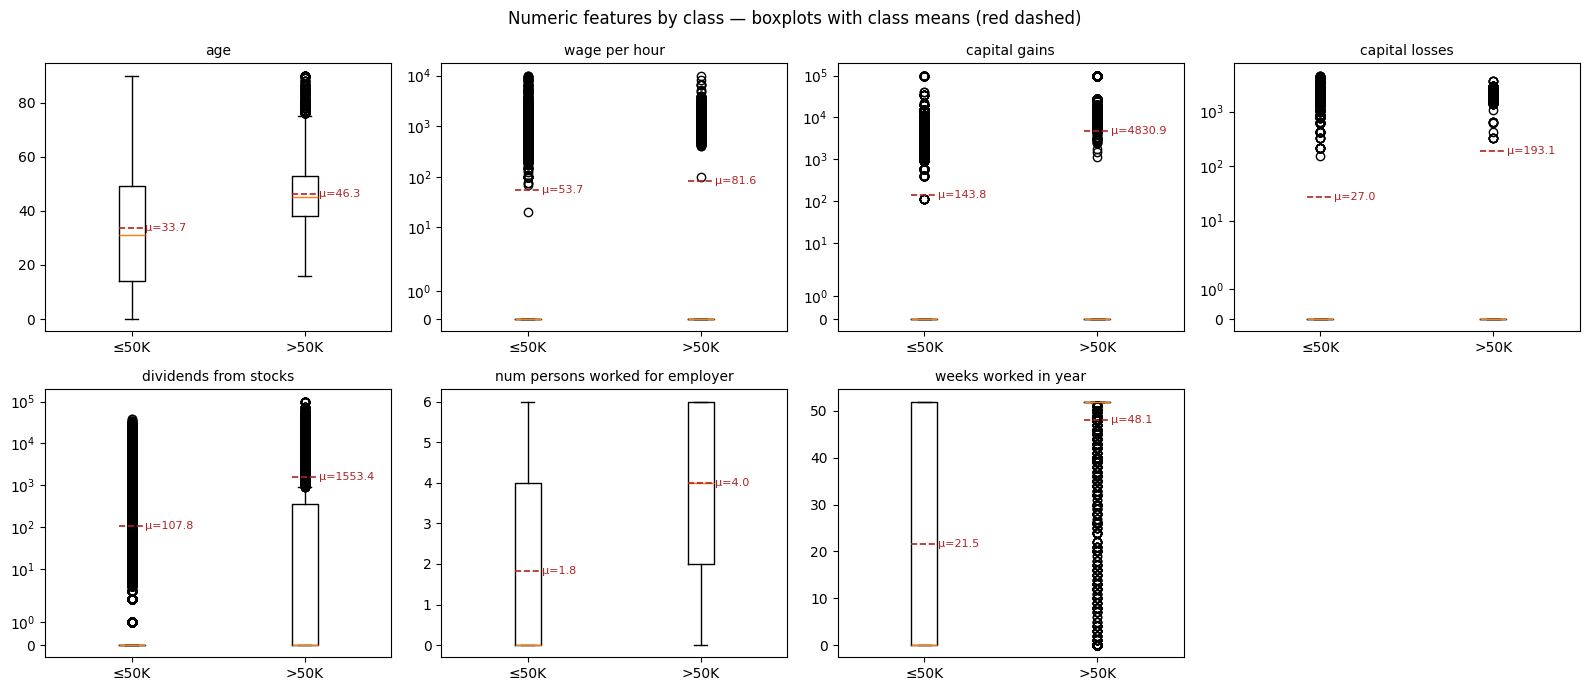

In [ ]:
# Numeric features by class — boxplots with class-mean annotations (symlog y for heavy-tailed)
heavy_tailed_set = {"wage per hour", "capital gains", "capital losses", "dividends from stocks"}
means_by_class = df.groupby("over_50k")[numeric_features].mean()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, c in enumerate(numeric_features):
    data_low = df.loc[df["over_50k"] == 0, c]
    data_high = df.loc[df["over_50k"] == 1, c]
    axes[i].boxplot(
        [data_low, data_high],
        tick_labels=["≤50K", ">50K"],
        showfliers=True,
        showmeans=True,
        meanline=True,
        meanprops={"color": "firebrick", "linewidth": 1.2},
    )
    axes[i].set_title(c, fontsize=10)
    if c in heavy_tailed_set:
        axes[i].set_yscale("symlog")
    mean_low = means_by_class.loc[0, c]
    mean_high = means_by_class.loc[1, c]
    axes[i].text(1.08, mean_low, f"μ={mean_low:.1f}", va="center", fontsize=8, color="firebrick")
    axes[i].text(2.08, mean_high, f"μ={mean_high:.1f}", va="center", fontsize=8, color="firebrick")

axes[7].axis("off")
fig.suptitle("Numeric features by class — boxplots with class means (red dashed)", fontsize=12)
fig.tight_layout()
plt.show()

<a id="obs-bivariate"></a>

### Observations

| # | Observation | Next step |
|---|---|---|
| 1 | **Education is the strongest single discriminator** — spread of 54pp across categories. `Prof school degree` → 54.04% (8.71×), `Doctorate` → 52.02% (8.38×), `Masters` → 31.16% (5.02×), `Bachelors` → 19.71% (3.18×). Near-monotonic ladder by attainment. | Carry `education` as a feature; education-tier indicators explored in the [feature-engineering section](#ch-feature-engineering-signals). |
| 2 | **Occupation, industry, and worker class carry strong signal**. Top detailed-occupation codes (7, 11) hit 66–68% income rate (~11× lift) but on small populations. Broader groups such as `Executive admin and managerial` (28.76%) and `Professional specialty` (24.93%) have wider reach. `Self-employed-incorporated` is 34.73% vs. 12.91% for not incorporated. | Keep detailed and major occupation/industry initially; revisit redundancy via importance + ablation. Grouped high-income flags explored in the [feature-engineering section](#ch-feature-engineering-signals). |
| 3 | **Numeric features show clear class separation**. Means by class: `age` 33.7 vs. 46.3; `weeks worked in year` 21.5 vs. 48.1; `capital gains` 144 vs. 4,831 (≈34×); `dividends from stocks` 108 vs. 1,553 (≈14×). The heavy-tailed financial features carry the largest absolute contrast. | Pass raw numerics to tree models; threshold/non-zero/top-code indicators explored in the [feature-engineering section](#ch-feature-engineering-signals). |
| 4 | **Household and demographic features are moderate signals**: `Married-civilian spouse present` 11.40%; `Householder` 14.74%; `Male` 10.17%; joint tax filing 13.14%; nonfilers near zero. Smaller than education/occupation but likely complementary. | Keep as auxiliary categorical features; expect interaction effects with education, work status, and age. |
| 5 | **Low-signal features confirmed**: migration codes (spread ≤6.6pp, lift ~1×); `year` (spread 0.71pp); `state/region of previous residence` (spread ≤3.5pp). | Confirms [categorical scan obs #6](#obs-categorical) drop candidates. Modeling notebook will run empirical importance check before final decision. |
| 6 | **Bivariate-only caveat**: these are univariate signals. Education and occupation likely share variance; `weeks worked`, `age`, marital status, and household role are also related. Multivariate feature importance in the model will resolve overlaps. | Treat findings as the analytical narrative for the report; do not drop low-bivariate features without checking multivariate importance. |

<a id="ch-feature-engineering-signals"></a>

## Feature-engineering candidates

- Address [bivariate observations](#obs-bivariate) #1–3 and [Key findings](#key-findings) rows 8–11.
- Translate the strongest univariate relationships into candidate features for `02_classification.ipynb`. Charts are the primary evidence for the final report (signal strength alongside segment size); the small tables underneath keep exact values auditable.
- Tree models can often learn these splits from raw categories. Linear models and segmentation rules typically benefit from explicit grouped indicators.
- *For the report:* provides the menu of grouped-indicator candidate features the linear baseline and segmentation rules will draw from.

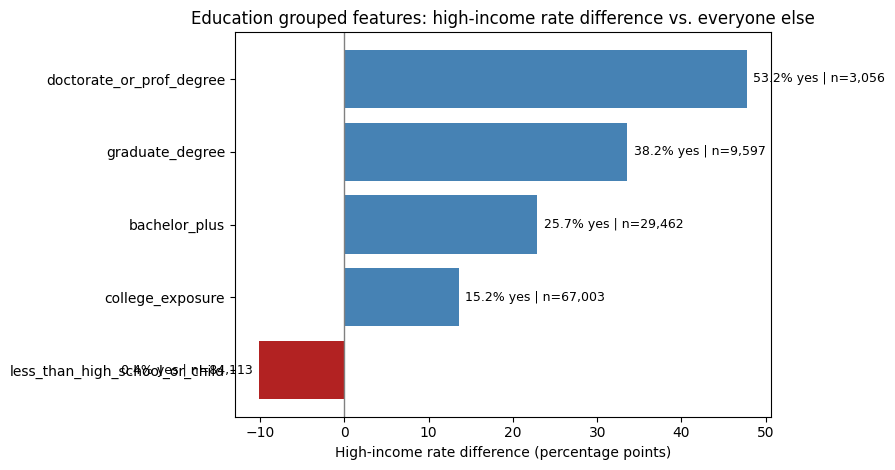

,candidate_feature,yes_n,yes_share_pct,yes_income_rate_pct,no_income_rate_pct,delta_vs_no_pp,yes_lift
0,doctorate_or_prof_degree,3056,1.53,53.21,5.47,47.73,8.57
1,graduate_degree,9597,4.81,38.18,4.59,33.59,6.15
2,bachelor_plus,29462,14.77,25.72,2.82,22.90,4.15
3,college_exposure,67003,33.58,15.21,1.65,13.56,2.45
4,less_than_high_school_or_child,84113,42.16,0.37,10.46,-10.09,0.06


In [ ]:
# Education tier candidates: show whether signal is PhD-only or broader degree attainment
base_rate = df["over_50k"].mean()


def binary_candidate_summary(candidates: dict[str, pd.Series]) -> pd.DataFrame:
    rows = []
    for name, mask in candidates.items():
        mask = mask.fillna(False).astype(bool)
        yes_rate = df.loc[mask, "over_50k"].mean()
        no_rate = df.loc[~mask, "over_50k"].mean()
        rows.append({
            "candidate_feature": name,
            "yes_n": int(mask.sum()),
            "yes_share_pct": mask.mean() * 100,
            "yes_income_rate_pct": yes_rate * 100,
            "no_income_rate_pct": no_rate * 100,
            "delta_vs_no_pp": (yes_rate - no_rate) * 100,
            "yes_lift": yes_rate / base_rate,
        })
    return pd.DataFrame(rows).sort_values("delta_vs_no_pp", ascending=True)


education_candidates = {
    "doctorate_or_prof_degree": df["education"].isin([
        "Doctorate degree(PhD EdD)",
        "Prof school degree (MD DDS DVM LLB JD)",
    ]),
    "graduate_degree": df["education"].isin([
        "Doctorate degree(PhD EdD)",
        "Prof school degree (MD DDS DVM LLB JD)",
        "Masters degree(MA MS MEng MEd MSW MBA)",
    ]),
    "bachelor_plus": df["education"].isin([
        "Doctorate degree(PhD EdD)",
        "Prof school degree (MD DDS DVM LLB JD)",
        "Masters degree(MA MS MEng MEd MSW MBA)",
        "Bachelors degree(BA AB BS)",
    ]),
    "college_exposure": df["education"].isin([
        "Doctorate degree(PhD EdD)",
        "Prof school degree (MD DDS DVM LLB JD)",
        "Masters degree(MA MS MEng MEd MSW MBA)",
        "Bachelors degree(BA AB BS)",
        "Associates degree-academic program",
        "Associates degree-occup /vocational",
        "Some college but no degree",
    ]),
    "less_than_high_school_or_child": df["education"].isin([
        "Children",
        "Less than 1st grade",
        "1st 2nd 3rd or 4th grade",
        "5th or 6th grade",
        "7th and 8th grade",
        "9th grade",
        "10th grade",
        "11th grade",
        "12th grade no diploma",
    ]),
}

education_feature_candidates = binary_candidate_summary(education_candidates)

plot_df = education_feature_candidates.copy()
colors = np.where(plot_df["delta_vs_no_pp"] >= 0, "steelblue", "firebrick")
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(plot_df["candidate_feature"], plot_df["delta_vs_no_pp"], color=colors)
ax.axvline(0, color="gray", linewidth=1)
ax.set_title("Education grouped features: high-income rate difference vs. everyone else")
ax.set_xlabel("High-income rate difference (percentage points)")
ax.set_ylabel("")
for _, row in plot_df.iterrows():
    x = row["delta_vs_no_pp"]
    ha = "left" if x >= 0 else "right"
    offset = 0.8 if x >= 0 else -0.8
    ax.text(x + offset, row["candidate_feature"], f'{row["yes_income_rate_pct"]:.1f}% yes | n={row["yes_n"]:,}', va="center", ha=ha, fontsize=9)
fig.tight_layout()
plt.show()

education_feature_candidates.sort_values("delta_vs_no_pp", ascending=False).round(2)

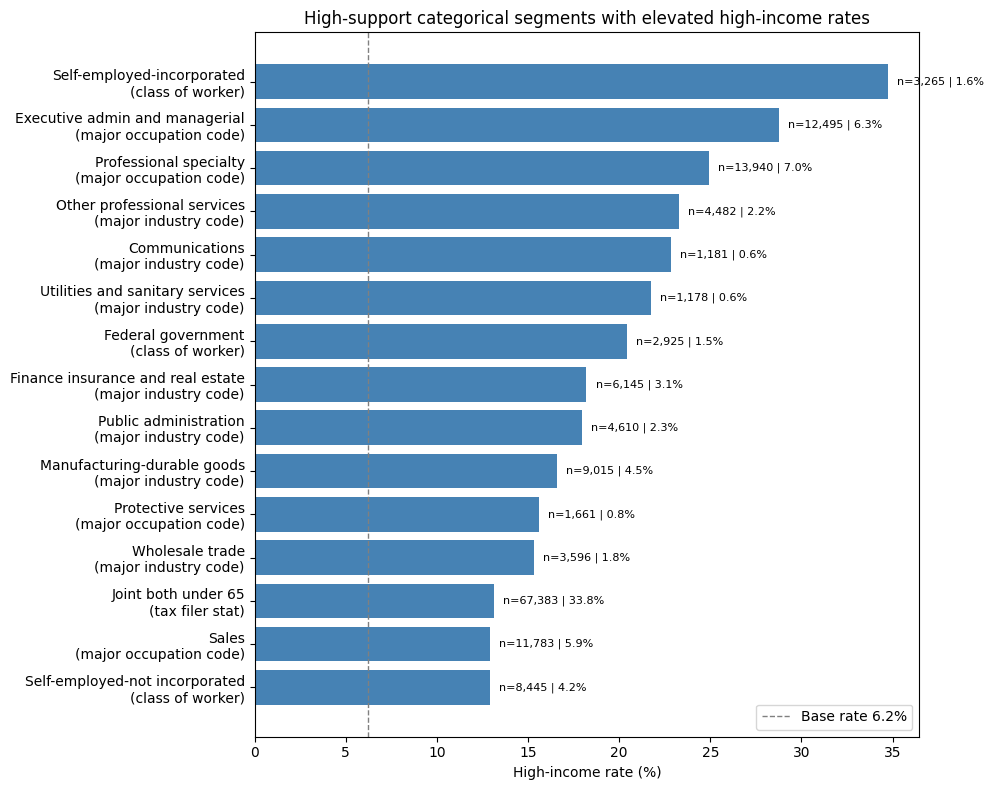

,feature,category,n,share_pct,income_rate_pct,lift
37,class of worker,Self-employed-incorporated,3265,1.64,34.73,5.60
1,major occupation code,Executive admin and managerial,12495,6.26,28.76,4.63
8,major occupation code,Professional specialty,13940,6.99,24.93,4.02
25,major industry code,Other professional services,4482,2.25,23.29,3.75
15,major industry code,Communications,1181,0.59,22.86,3.68
31,major industry code,Utilities and sanitary services,1178,0.59,21.73,3.50
33,class of worker,Federal government,2925,1.47,20.41,3.29
19,major industry code,Finance insurance and real estate,6145,3.08,18.21,2.93
27,major industry code,Public administration,4610,2.31,17.94,2.89
21,major industry code,Manufacturing-durable goods,9015,4.52,16.57,2.67


In [23]:
# High-support categorical segments that may become grouped flags for linear models or segmentation.
selected_signal_columns = [
    "major occupation code",
    "major industry code",
    "class of worker",
    "marital stat",
    "tax filer stat",
    "detailed household summary in household",
    "sex",
]

segment_rows = []
min_share = 0.005  # keep categories covering at least 0.5% of records
for col in selected_signal_columns:
    rates = (
        df.groupby(col, observed=True)["over_50k"]
        .agg(n="size", income_rate="mean")
        .reset_index()
    )
    rates["feature"] = col
    rates["category"] = rates[col].astype(str)
    rates["share_pct"] = rates["n"] / len(df) * 100
    rates["income_rate_pct"] = rates["income_rate"] * 100
    rates["lift"] = rates["income_rate"] / base_rate
    segment_rows.append(rates.loc[rates["share_pct"] >= min_share * 100, [
        "feature", "category", "n", "share_pct", "income_rate_pct", "lift"
    ]])

strong_categorical_segments = (
    pd.concat(segment_rows, ignore_index=True)
    .sort_values(["income_rate_pct", "share_pct"], ascending=[False, False])
    .head(15)
)

plot_df = strong_categorical_segments.sort_values("income_rate_pct", ascending=True).copy()
plot_df["label"] = plot_df["category"].str.slice(0, 38) + "\n(" + plot_df["feature"] + ")"
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["label"], plot_df["income_rate_pct"], color="steelblue")
ax.axvline(base_rate * 100, color="gray", linestyle="--", linewidth=1, label=f"Base rate {base_rate * 100:.1f}%")
ax.set_title("High-support categorical segments with elevated high-income rates")
ax.set_xlabel("High-income rate (%)")
ax.set_ylabel("")
for _, row in plot_df.iterrows():
    ax.text(row["income_rate_pct"] + 0.5, row["label"], f'n={row["n"]:,} | {row["share_pct"]:.1f}%', va="center", fontsize=8)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

strong_categorical_segments.round(2)

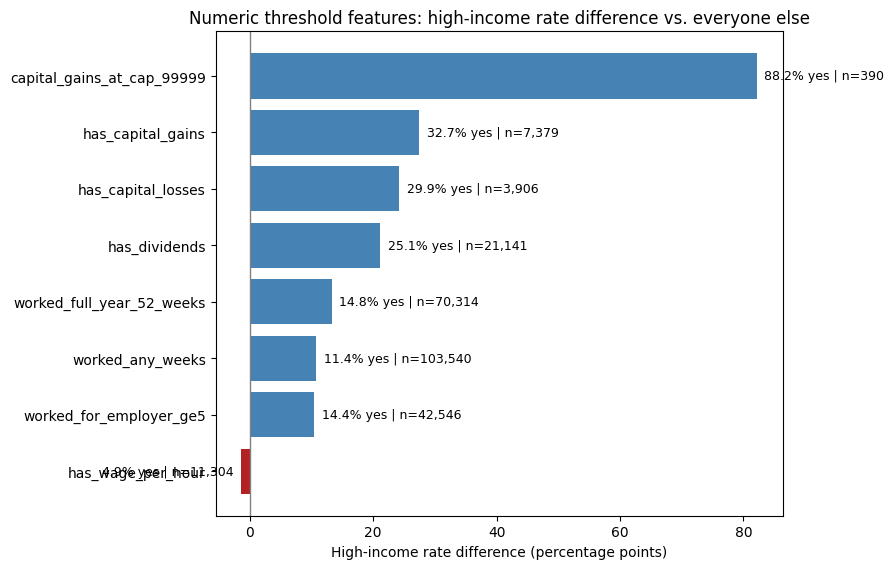

,candidate_feature,yes_n,yes_share_pct,yes_income_rate_pct,no_income_rate_pct,delta_vs_no_pp,yes_lift
0,capital_gains_at_cap_99999,390,0.20,88.21,6.05,82.16,14.21
1,has_capital_gains,7379,3.70,32.69,5.19,27.50,5.27
2,has_capital_losses,3906,1.96,29.93,5.73,24.20,4.82
3,has_dividends,21141,10.60,25.12,3.96,21.16,4.05
4,worked_full_year_52_weeks,70314,35.24,14.80,1.53,13.27,2.38
5,worked_any_weeks,103540,51.89,11.38,0.62,10.76,1.83
6,worked_for_employer_ge5,42546,21.32,14.44,3.97,10.47,2.33
7,has_wage_per_hour,11304,5.67,4.92,6.28,-1.36,0.79


In [24]:
# Numeric candidates: zero/non-zero flags, top-code flag, and labor-intensity thresholds.
numeric_candidates = {
    "capital_gains_at_cap_99999": df["capital gains"] == 99_999,
    "has_capital_gains": df["capital gains"] > 0,
    "has_capital_losses": df["capital losses"] > 0,
    "has_dividends": df["dividends from stocks"] > 0,
    "worked_full_year_52_weeks": df["weeks worked in year"] == 52,
    "worked_any_weeks": df["weeks worked in year"] > 0,
    "worked_for_employer_ge5": df["num persons worked for employer"] >= 5,
    "has_wage_per_hour": df["wage per hour"] > 0,
}

numeric_feature_candidates = binary_candidate_summary(numeric_candidates)

plot_df = numeric_feature_candidates.sort_values("delta_vs_no_pp", ascending=True).copy()
colors = np.where(plot_df["delta_vs_no_pp"] >= 0, "steelblue", "firebrick")
fig, ax = plt.subplots(figsize=(9, 5.8))
ax.barh(plot_df["candidate_feature"], plot_df["delta_vs_no_pp"], color=colors)
ax.axvline(0, color="gray", linewidth=1)
ax.set_title("Numeric threshold features: high-income rate difference vs. everyone else")
ax.set_xlabel("High-income rate difference (percentage points)")
ax.set_ylabel("")
for _, row in plot_df.iterrows():
    x = row["delta_vs_no_pp"]
    ha = "left" if x >= 0 else "right"
    offset = 1.2 if x >= 0 else -1.2
    ax.text(x + offset, row["candidate_feature"], f'{row["yes_income_rate_pct"]:.1f}% yes | n={row["yes_n"]:,}', va="center", ha=ha, fontsize=9)
fig.tight_layout()
plt.show()

numeric_feature_candidates.sort_values("delta_vs_no_pp", ascending=False).round(2)

<a id="obs-feature-engineering"></a>

### Observations

| # | Observation | Next step |
|---|---|---|
| 1 | **Education-tier flags confirm the signal is not PhD-only**: `doctorate_or_prof_degree` 53.21% vs. 5.47% (47.7pp delta); `graduate_degree` 38.18% vs. 4.59% (33.6pp); `bachelor_plus` 25.72% vs. 2.82% (22.9pp). Each tier carries large absolute lift on a meaningful share of records. | Test `doctorate_or_prof_degree`, `graduate_degree`, and `bachelor_plus` for the linear baseline and segmentation rules. |
| 2 | **High-support categorical segments cluster around occupation, worker class, marital, household, and tax-filer status**: exec/managerial, professional specialty, self-employed-incorporated, married-civilian-spouse-present, householder, joint tax filers. Top-15 high-support segments shown in the figure. | Test grouped high-income work-category flags as auxiliary linear-model features and segmentation rules. |
| 3 | **Numeric threshold flags carry strong binary signal**: `capital_gains_at_cap_99999` → 88.21% high-income; `has_capital_gains` 32.69% vs. 5.19%; `has_capital_losses` 29.93% vs. 5.73%; `has_dividends` 25.12% vs. 3.96%; `worked_full_year_52_weeks` 14.80% vs. 1.53%. Tail and zero-spike events are where the binary signal lives. | Test these flags in the linear baseline; trees can absorb them from raw values, but the flags help calibration and interpretability. |
| 4 | All candidates are validated against the EDA evidence but not yet against the modeling target. | Treat this as the menu of candidate features for `02_classification.ipynb`; test empirically via importance + ablation. |